In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print("Libraries successfully imported.")


TensorFlow Version: 2.20.0
Libraries successfully imported.


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Dataset path
DATA_DIR = "/content/drive/MyDrive/Brain Tumor/d1"
EXPORT_DIR = "/content/drive/MyDrive/Brain Tumor"
os.makedirs(EXPORT_DIR, exist_ok=True)

print(f"Dataset path set to: {DATA_DIR}")


Mounted at /content/drive
Dataset path set to: /content/drive/MyDrive/Brain Tumor/d1


In [ ]:
# Verify Dataset File Counts
# Verify class distribution
categories = ['no', 'yes']
for category in categories:
    category_path = os.path.join(DATA_DIR, category)
    if os.path.exists(category_path):
        num_images = len([f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"Class '{category}': {num_images} images found.")
    else:
        print(f"Directory not found for class: {category}")

Class 'no': 1500 images found.
Class 'yes': 1530 images found.


In [ ]:
#Load & Split Dataset (Train / Validation)
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Load training dataset (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary"
)

# Load validation dataset (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary"
)

class_names = train_ds.class_names
print(f"Identified Classes: {class_names}")

# Optimize pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 3030 files belonging to 2 classes.
Using 2424 files for training.
Found 3030 files belonging to 2 classes.
Using 606 files for validation.
Identified Classes: ['no', 'yes']


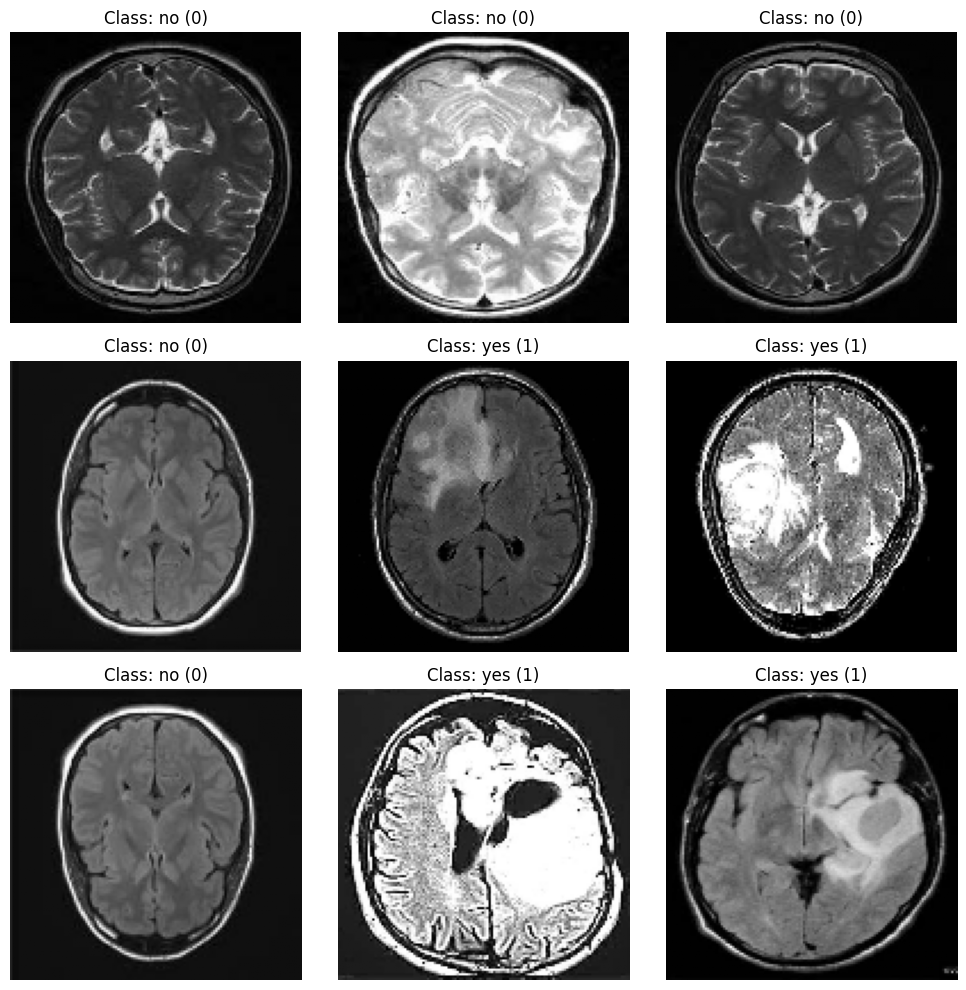

In [ ]:
#Visualize Sample Images
# Display sample images from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        class_idx = int(labels[i].numpy()[0])
        plt.title(f"Class: {class_names[class_idx]} ({class_idx})")
        plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:

#Fast & Lightweight CNN Architecture
def build_fast_brain_cnn(input_shape=(128, 128, 1)):
    model = models.Sequential([
        # Input Layer
        layers.Input(shape=input_shape),

        # Rescaling pixel values to [0, 1]
        layers.Rescaling(1./255),

        # Fast Augmentation (Horizontal Flip is very fast on CPU)
        layers.RandomFlip("horizontal"),

        # Block 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Classification Head
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    return model

model = build_fast_brain_cnn()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,189,953 (8.35 MB)

 Trainable params: 2,189,953 (8.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Optimized Callbacks
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Define Callbacks with shorter patience
model_save_path = os.path.join(EXPORT_DIR, "best_brain_tumor_model.keras")

callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=model_save_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print(f"Model checkpoint configured: {model_save_path}")

Model checkpoint configured: /content/drive/MyDrive/Brain Tumor/best_brain_tumor_model.keras


In [9]:
# Train for 20 epochs (EarlyStopping will stop it automatically if converged)

# Fast Trainin
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)


Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.9964 - loss: 0.0142
Epoch 1: val_loss did not improve from 0.05859
76/76 ━━━━━━━━━━━━━━━━━━━━ 74s 972ms/step - accuracy: 0.9979 - loss: 0.0102 - val_accuracy: 0.9802 - val_loss: 0.0758 - learning_rate: 5.0000e-04
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.9979 - loss: 0.0059
Epoch 2: val_loss did not improve from 0.05859
76/76 ━━━━━━━━━━━━━━━━━━━━ 64s 847ms/step - accuracy: 0.9979 - loss: 0.0059 - val_accuracy: 0.9802 - val_loss: 0.0715 - learning_rate: 5.0000e-04
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.9988 - loss: 0.0049
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 3: val_loss did not improve from 0.05859
76/76 ━━━━━━━━━━━━━━━━━━━━ 80s 824ms/step - accuracy: 0.9983 - loss: 0.0055 - val_accuracy: 0.9802 - val_loss: 0.0858 - learning_rate: 5.0000e-04
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.9977 - loss: 0.0072


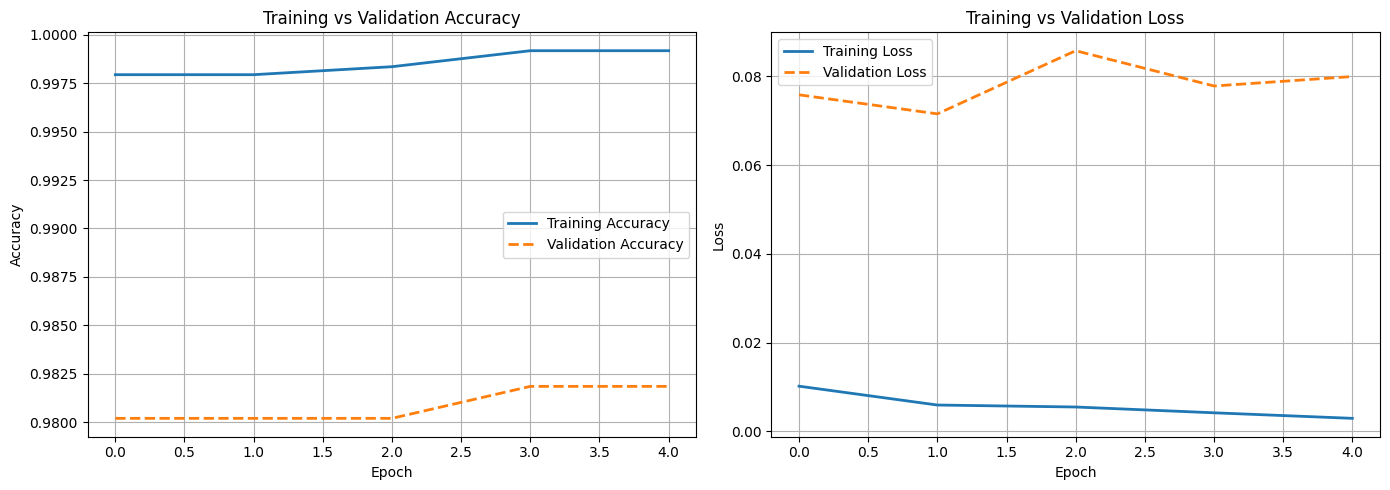

In [10]:
#Plot Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
axes[0].set_title('Training vs Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot Loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
axes[1].set_title('Training vs Validation Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



--- Model Classification Report ---
              precision    recall  f1-score   support

          no     0.9863    0.9729    0.9795       295
         yes     0.9746    0.9871    0.9808       311

    accuracy                         0.9802       606
   macro avg     0.9804    0.9800    0.9802       606
weighted avg     0.9803    0.9802    0.9802       606



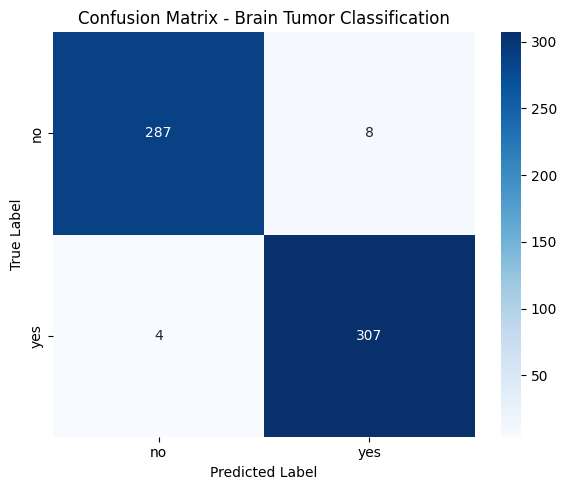

In [11]:
#Quantitative Evaluation (Confusion Matrix & Classification Report)
# Collect true labels and predictions
y_true_all = []
y_pred_probs_all = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true_all.extend(labels.numpy().flatten())
    y_pred_probs_all.extend(preds.flatten())

y_true_all = np.array(y_true_all).astype(int)
y_pred_all = (np.array(y_pred_probs_all) >= 0.5).astype(int)

# Classification Report
print("\n--- Model Classification Report ---")
print(classification_report(y_true_all, y_pred_all, target_names=class_names, digits=4))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Brain Tumor Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


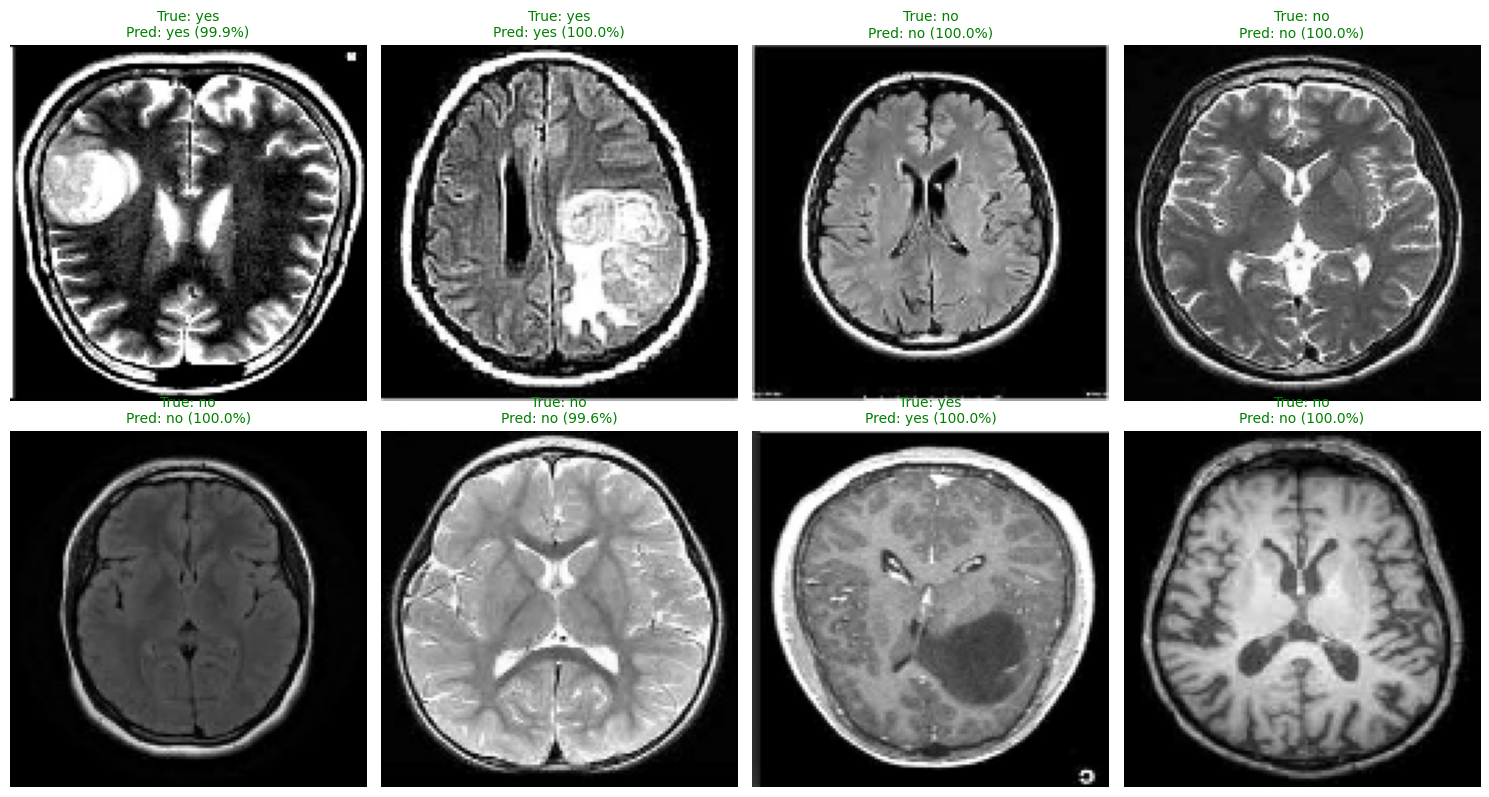

In [12]:
#Visual Sample Prediction Verification
for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0).flatten()

    plt.figure(figsize=(15, 8))
    num_to_display = min(8, len(labels))

    for i in range(num_to_display):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")

        prob = preds[i]
        pred_class = 1 if prob >= 0.5 else 0
        confidence = prob if pred_class == 1 else (1 - prob)

        true_label = int(labels[i].numpy()[0])
        is_correct = (pred_class == true_label)
        status_color = "green" if is_correct else "red"

        ax.set_title(
            f"True: {class_names[true_label]}\nPred: {class_names[pred_class]} ({confidence*100:.1f}%)",
            color=status_color,
            fontsize=10
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [13]:
# Single Image Inference Function

def predict_single_mri(image_path, model, class_names, target_size=(128, 128)):
    if not os.path.exists(image_path):
        print(f"Error: File not found at {image_path}")
        return

    img = tf.keras.utils.load_img(image_path, color_mode="grayscale", target_size=target_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prob = model.predict(img_array, verbose=0)[0][0]
    pred_idx = 1 if prob >= 0.5 else 0
    confidence = prob if pred_idx == 1 else (1 - prob)

    print("\n" + "="*40)
    print(f"Image: {os.path.basename(image_path)}")
    print(f"Predicted Diagnosis: {class_names[pred_idx].upper()}")
    print(f"Confidence Score: {confidence * 100:.2f}%")
    print("="*40 + "\n")

# Example execution:
# sample_test_path = os.path.join(DATA_DIR, "yes", os.listdir(os.path.join(DATA_DIR, "yes"))[0])
# predict_single_mri(sample_test_path, model, class_names)


Successfully loaded model from: /content/drive/MyDrive/Brain Tumor/best_brain_tumor_model.keras
Ground Truth Class: 'no'
Sample File: no558.jpg
Model Prediction: NO
Confidence Score: 100.00%
Ground Truth Class: 'yes'
Sample File: y995.jpg
Model Prediction: YES
Confidence Score: 99.98%


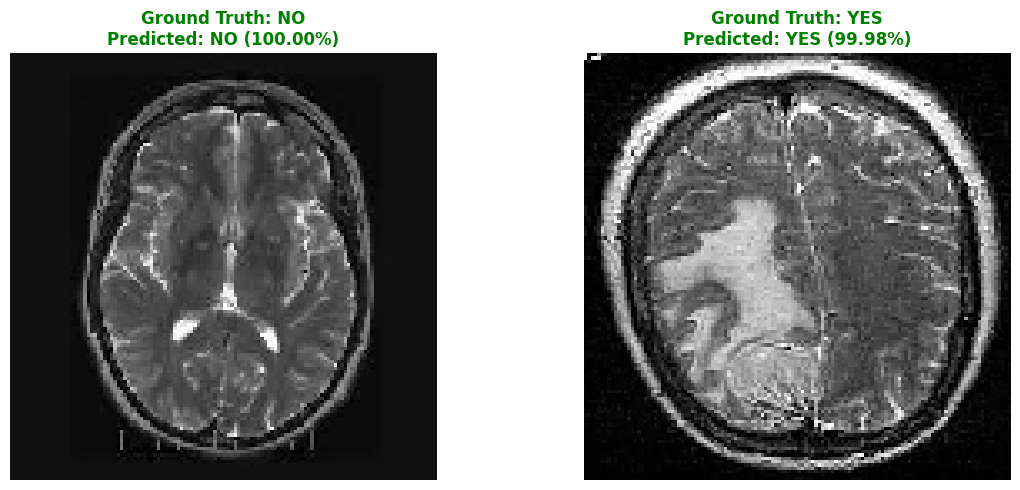

In [14]:
# =======================================================
# Cell 12: Load Saved Model & Standalone Inference Test
# =======================================================

# Path to the saved model
saved_model_path = os.path.join(EXPORT_DIR, "best_brain_tumor_model.keras")

# 1. Load the model from disk
if os.path.exists(saved_model_path):
    deployed_model = tf.keras.models.load_model(saved_model_path)
    print(f"Successfully loaded model from: {saved_model_path}")
else:
    raise FileNotFoundError(f"Model file not found at: {saved_model_path}")


# 2. Inference function using the loaded model
def predict_single_mri(image_path, model, class_names, target_size=(128, 128)):
    if not os.path.exists(image_path):
        print(f"Error: File not found at {image_path}")
        return None, None, None

    img = tf.keras.utils.load_img(image_path, color_mode="grayscale", target_size=target_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict probability
    prob = model.predict(img_array, verbose=0)[0][0]
    pred_idx = 1 if prob >= 0.5 else 0
    confidence = prob if pred_idx == 1 else (1 - prob)

    return class_names[pred_idx], confidence, img


# 3. Test loaded model on random sample images from disk
plt.figure(figsize=(12, 5))

for idx, true_category in enumerate(['no', 'yes']):
    folder_path = os.path.join(DATA_DIR, true_category)
    available_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(available_files) > 0:
        sample_file = random.choice(available_files)
        sample_path = os.path.join(folder_path, sample_file)

        # Run inference using the loaded model
        predicted_label, conf, img_obj = predict_single_mri(sample_path, deployed_model, class_names)

        # Display log in console
        print("=" * 45)
        print(f"Ground Truth Class: '{true_category}'")
        print(f"Sample File: {sample_file}")
        print(f"Model Prediction: {predicted_label.upper()}")
        print(f"Confidence Score: {conf * 100:.2f}%")
        print("=" * 45)

        # Visualize diagnosis output
        ax = plt.subplot(1, 2, idx + 1)
        plt.imshow(img_obj, cmap="gray")
        is_correct = (predicted_label == true_category)
        color = "green" if is_correct else "red"

        plt.title(
            f"Ground Truth: {true_category.upper()}\nPredicted: {predicted_label.upper()} ({conf*100:.2f}%)",
            color=color,
            fontsize=12,
            fontweight='bold'
        )
        plt.axis("off")

plt.tight_layout()
plt.show()
